# **1. Import Library**
Pada tahap ini, perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
!pip install nltk
!pip install nlpaug
!pip install Sastrawi
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import wordninja
import random
import joblib

import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **2. Memuat Dataset dari Hasil Scrapping**
Memuat dataset hasil scrapping dari file CSV ke dalam variabel DataFrame.

In [5]:
datafile = pd.read_csv('ulasanDPS.csv')
print(datafile.head())
print(datafile.tail())
print(datafile.info()) # Menampilkan tipe data dan info memori
print(datafile.isnull().sum()) # Mengecek jumlah data kosong di setiap kolom

                                              ulasan  rating sentiment
0  Banyak cctv yg tidak bisa menampilkan kondisi ...       2   negatif
1  1 bintang dulu ya. Tiang sudah dari kemarin do...       1   negatif
2  Saat membuat pengaduan aplikasi tiba2 crash da...       1   negatif
3  menu Daftar masih eror, Menu Live CCTV masih E...       2   negatif
4  Saya sudah donlod dan gak berguna sama skali, ...       1   negatif
                    ulasan  rating sentiment
149                 Mantap       5   positif
150                    top       5   positif
151               Mantapp💪       5   positif
152  Inspirasi banget😍😍😍😍😍       5   positif
153        Sangat membantu       5   positif
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ulasan     154 non-null    object
 1   rating     154 non-null    int64 
 2   sentiment  154 non-null    object
dtype

# **3. Preprocessing Teks**
Tahap Preprocessing bertujuan untuk membersihkan dataset agar dapat digunakan untuk melatih model machine learning.

In [6]:
datafile['lowercase'] = datafile['ulasan'].str.lower()

casefolding = pd.DataFrame(datafile['lowercase'])
print(casefolding)

                                             lowercase
0    banyak cctv yg tidak bisa menampilkan kondisi ...
1    1 bintang dulu ya. tiang sudah dari kemarin do...
2    saat membuat pengaduan aplikasi tiba2 crash da...
3    menu daftar masih eror, menu live cctv masih e...
4    saya sudah donlod dan gak berguna sama skali, ...
..                                                 ...
149                                             mantap
150                                                top
151                                           mantapp💪
152                              inspirasi banget😍😍😍😍😍
153                                    sangat membantu

[154 rows x 1 columns]


In [7]:
def remove_punctuations(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) #menghapus mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) #menghapus hastag
    text = re.sub(r'RT[\s]', '', text) #menghapus rt
    text = re.sub(r"https\S+", '', text) #menghapus link
    text = re.sub(r'[0-9]+', '', text)

    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emotikon wajah
                           u"\U0001F300-\U0001F5FF"  # simbol & pictograph
                           u"\U0001F680-\U0001F6FF"  # transport & simbol
                           u"\U0001F1E0-\U0001F1FF"  # bendera
                           u"\U00002700-\U000027BF"  # simbol tambahan
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text)
    text = text.strip(' ')
    text = re.sub(r'(\w)\1+$', r'\1', text)
    return text

    # pisahkan kata nyambung
    split_words = []
    for word in text.split():
        split_words += wordninja.split(word)
    
    return ' '.join(split_words)
    
datafile['cleanpunct'] = datafile['lowercase'].apply(remove_punctuations)
cleanpunct = pd.DataFrame(datafile['cleanpunct'])
print(cleanpunct)

                                            cleanpunct
0    banyak cctv yg tidak bisa menampilkan kondisi ...
1    bintang dulu ya tiang sudah dari kemarin downl...
2    saat membuat pengaduan aplikasi tiba crash dan...
3    menu daftar masih eror menu live cctv masih er...
4    saya sudah donlod dan gak berguna sama skali m...
..                                                 ...
149                                             mantap
150                                                top
151                                             mantap
152                                   inspirasi banget
153                                    sangat membantu

[154 rows x 1 columns]


In [8]:
custom_stopwords = {'ya', 'nya', 'deh', 'sih', 'kok', 'dong', 'lah', 'kan', 'nyak', 'bsa', 'deh', 'nah', 'hm', 'je'}

def tokenizingText(text):
    tokens = word_tokenize(text)
    filtered = [t for t in tokens if t.lower() not in custom_stopwords]
    return filtered

datafile['tokens'] = datafile['cleanpunct'].apply(tokenizingText)

tokenize = pd.DataFrame(datafile['tokens'])
print(tokenize)

                                                tokens
0    [banyak, cctv, yg, tidak, bisa, menampilkan, k...
1    [bintang, dulu, tiang, sudah, dari, kemarin, d...
2    [saat, membuat, pengaduan, aplikasi, tiba, cra...
3    [menu, daftar, masih, eror, menu, live, cctv, ...
4    [saya, sudah, donlod, dan, gak, berguna, sama,...
..                                                 ...
149                                           [mantap]
150                                              [top]
151                                           [mantap]
152                                [inspirasi, banget]
153                                 [sangat, membantu]

[154 rows x 1 columns]


In [9]:
normalized_word = pd.read_csv('normalisasi_variasi.csv')

normalized_word_dict = {}
for index, row in normalized_word.iterrows():
   if row['kata_tidak_baku'] not in normalized_word_dict:
        normalized_word_dict[row['kata_tidak_baku']] = row['kata_baku']
        
def normalized(document):
    return [normalized_word_dict[term] if term in normalized_word_dict else term for term in document]

datafile['normalization'] = datafile['tokens'].apply(normalized)
normalization = pd.DataFrame(datafile['normalization'])
print(normalization)

                                         normalization
0    [banyak, cctv, yang, tidak, bisa, menampilkan,...
1    [bintang, dulu, saya, sudah, dari, kemarin, do...
2    [saat, membuat, pengaduan, aplikasi, tiba, cra...
3    [menu, daftar, masih, error, menu, live, cctv,...
4    [saya, sudah, download, dan, tidak, berguna, s...
..                                                 ...
149                                           [mantap]
150                                              [top]
151                                           [mantap]
152                                [inspirasi, banget]
153                                 [sangat, membantu]

[154 rows x 1 columns]


In [10]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
   stems = [stemmer.stem(word) for word in tokens]
   return ' '.join(stems)

datafile['stemming'] = datafile['normalization'].apply(stemming)
stemming = pd.DataFrame(datafile['stemming'])
print(stemming)

                                              stemming
0    banyak cctv yang tidak bisa tampil kondisi tia...
1    bintang dulu saya sudah dari kemarin download ...
2    saat buat adu aplikasi tiba crash dan logout c...
3    menu daftar masih error menu live cctv masih e...
4    saya sudah download dan tidak guna sama sekali...
..                                                 ...
149                                             mantap
150                                                top
151                                             mantap
152                                   inspirasi banget
153                                       sangat bantu

[154 rows x 1 columns]


In [11]:
def clean_stopwords(tokens):
    stopword_id= set(stopwords.words('indonesian'))
    stopword_eng = set(stopwords.words('english'))
    text = [word for word in tokens if word not in stopword_id and word not in stopword_eng]
    return text
    
datafile['tokens'] = datafile['stemming'].apply(word_tokenize)

datafile['stopword'] = datafile['tokens'].apply(clean_stopwords)

datafile['stopword_str'] = datafile['stopword'].apply(lambda x: ' '.join(x))

stopword = pd.DataFrame(datafile['stopword_str'])
print(stopword)

datafile[['lowercase', 'cleanpunct', 'tokens', 'normalization', 'stemming', 'stopword_str', 'rating', 'sentiment']].to_csv('preprocessing_DPS.csv', index=False)
print("File berhasil disimpan.")

                                          stopword_str
0    cctv tampil kondisi simpang tampil gambar posi...
1    bintang kemarin download registrasi salah coba...
2    adu aplikasi crash logout adu ulang mohon semp...
3    menu daftar error menu live cctv error menu in...
4    download daftar muncul kalimat salah server kl...
..                                                 ...
149                                             mantap
150                                                top
151                                             mantap
152                                   inspirasi banget
153                                              bantu

[154 rows x 1 columns]
File berhasil disimpan.


In [12]:
# Baca dataset hasil labeling
final_df = pd.read_csv('preprocessing_DPS.csv')

selected_columns = final_df[['stopword_str', 'rating', 'sentiment']]

# Hapus baris yang nilai 'stopword_str' kosong atau NaN
selected_columns = selected_columns.dropna(subset=['stopword_str'])

selected_columns = selected_columns[selected_columns['stopword_str'].str.strip() != ""]

# Cek hasil
print(selected_columns.head())
print(selected_columns['sentiment'].value_counts())

selected_columns.to_csv('komentar_DPS.csv', index=False)

                                        stopword_str  rating sentiment
0  cctv tampil kondisi simpang tampil gambar posi...       2   negatif
1  bintang kemarin download registrasi salah coba...       1   negatif
2  adu aplikasi crash logout adu ulang mohon semp...       1   negatif
3  menu daftar error menu live cctv error menu in...       2   negatif
4  download daftar muncul kalimat salah server kl...       1   negatif
sentiment
positif    84
negatif    64
Name: count, dtype: int64


# **4. Augmentasi Data**
Tahap augmentasi data menggunakan sinonim bertujuan untuk balance dataset menjadikan jumlah data dengan sentimen positif dan negatif seimbang.

In [22]:
def load_kamus(csv_path):
    datafile = pd.read_csv(csv_path)
    datafile.columns = datafile.columns.str.strip().str.lower()
    kamus = {}
    for _, row in datafile.iterrows():
        base = row['kata'].strip().lower()
        kamus[base] = []
        for col in ['sinonim1', 'sinonim2', 'sinonim3']:
            if pd.notna(row[col]):
                kamus[base].append(row[col].strip().lower())
    return kamus


def aug_sinonim_kalimat(text, kamus, n=3):
    words = text.lower().split()
    new_words = words.copy()

    kandidat = [w for w in words if w in kamus and kamus[w]]
    if not kandidat:
        return text

    random.shuffle(kandidat)
    kandidat = kandidat[:min(n, len(kandidat))]

    for word in kandidat:
        if kamus[word]:
            synonym = random.choice(kamus[word])
            new_words = [synonym if w == word else w for w in new_words]

    return ' '.join(new_words)


def augment_dataset(input_csv, kamus_csv, output_csv):
    datafile = pd.read_csv(input_csv)
    kamus = load_kamus(kamus_csv)

    class_counts = datafile['sentiment'].value_counts()
    target_per_class = class_counts.max()
    print(f"Target augmentasi per kelas: {target_per_class}")
    print(f"Distribusi awal:\n{class_counts}\n")

    augmented_only = []

    for label in class_counts.index:
        label_df = datafile[datafile['sentiment'] == label]
        current_count = len(label_df)
        needed = target_per_class - current_count

        print(f"⏳ Sentimen: {label} | Saat ini: {current_count} | Dibutuhkan: {needed}")

        if needed <= 0:
            continue

        success_count = 0
        attempts = 0
        max_attempts = needed * 5

        while success_count < needed and attempts < max_attempts:
            row = label_df.sample(n=1, replace=True).iloc[0]
            original_text = row['stopword_str']
            augmented_text = aug_sinonim_kalimat(original_text, kamus, n=3)

            if augmented_text != original_text:
                augmented_only.append({
                    'stopword_str': augmented_text,
                    'sentiment': row['sentiment']
                })
                success_count += 1
            attempts += 1

        print(f"Ditambahkan untuk '{label}': {success_count} kalimat\n")

    # Simpan hasil augmentasi
    if augmented_only:
        augmented_df = pd.DataFrame(augmented_only)
        augmented_df.to_csv(output_csv, index=False)
        print(f"Augmentasi selesai. Total {len(augmented_only)} data ditambahkan ke '{output_csv}'")
    else:
        print("Tidak ada data yang berhasil diaugmentasi.")

if __name__ == "__main__":
    augment_dataset(
        input_csv='komentar_DPS.csv',
        kamus_csv='kamus_sinonim.csv',
        output_csv='augmentedDPS.csv'
    )

Target augmentasi per kelas: 84
Distribusi awal:
sentiment
positif    84
negatif    64
Name: count, dtype: int64

⏳ Sentimen: positif | Saat ini: 84 | Dibutuhkan: 0
⏳ Sentimen: negatif | Saat ini: 64 | Dibutuhkan: 20
Ditambahkan untuk 'negatif': 20 kalimat

Augmentasi selesai. Total 20 data ditambahkan ke 'augmentedDPS.csv'


In [23]:
datafile1 = pd.read_csv('augmentedDPS.csv')
datafile2 = pd.read_csv('komentar_DPS.csv')

final_datafile = pd.concat([datafile1, datafile2], ignore_index=True)

final_datafile.to_csv('dataset_DPS.csv', index=False)
print("File berhasil disimpan.")

File berhasil disimpan.


In [24]:
print("Distribusi data:\n", final_datafile['sentiment'].value_counts())

Distribusi data:
 sentiment
negatif    84
positif    84
Name: count, dtype: int64


# **5. Data Splitting**
Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [25]:
datafile = pd.read_csv("dataset_DPS.csv")

# Pisahkan fitur dan label
X = datafile['stopword_str'].astype(str)  
y = datafile['sentiment']                  

# Split 80% latih dan 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.DataFrame({'stopword_str': X_train, 'sentiment': y_train})
test_df = pd.DataFrame({'stopword_str': X_test, 'sentiment': y_test})

train_df.to_csv('data_train_DPS.csv', index=False)
test_df.to_csv('data_test_DPS.csv', index=False)

print("File data_train.csv dan data_test.csv berhasil disimpan.")

File data_train.csv dan data_test.csv berhasil disimpan.


In [26]:
print("Distribusi data latih:\n", y_train.value_counts())
print("Distribusi data uji:\n", y_test.value_counts())

Distribusi data latih:
 sentiment
negatif    67
positif    67
Name: count, dtype: int64
Distribusi data uji:
 sentiment
negatif    17
positif    17
Name: count, dtype: int64


# **6. Feature Extraction**
Tahap TF-IDF bertujuan untuk mengubah dataset kedalam  bentuk keyword bernilai numerik.

In [34]:
#Load Data
train_df = pd.read_csv("data_train_DPS.csv")
test_df = pd.read_csv("data_test_DPS.csv")

X_train_text = train_df['stopword_str'].astype(str)
y_train = train_df['sentiment']

X_test_text = test_df['stopword_str'].astype(str)
y_test = test_df['sentiment']

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 1)  # Unigram
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

feature_names = tfidf.get_feature_names_out()

def extract_top_keywords(doc_vector, feature_names, top_n=10):
    indices = np.argsort(doc_vector)[::-1][:top_n]
    return [feature_names[i] for i in indices]

dense_tfidf = X_train_tfidf.toarray()
all_keywords = [
    extract_top_keywords(vec, feature_names)
    for vec in dense_tfidf
]

df_keywords = pd.DataFrame({
    'stopword_str': X_train_text.values,
    'keywords': all_keywords,
})
df_keywords.to_csv('hasil_keywords_DPS.csv', index=False)

mean_tfidf = X_train_tfidf.mean(axis=0).A1
tfidf_scores = pd.DataFrame({
    'kata': feature_names,
    'skor_DPS': mean_tfidf
}).sort_values('skor_DPS', ascending=False)

print("20 Kata dengan skor TF-IDF tertinggi:")
print(tfidf_scores.head(20))

# Simpan vectorizer
joblib.dump(tfidf, "vectorizer_tfidf_DPS.joblib")

20 Kata dengan skor TF-IDF tertinggi:
           kata  skor_DPS
6      aplikasi  0.104950
25     denpasar  0.081297
7         bagus  0.061491
67       mantap  0.060794
63        login  0.057436
70   masyarakat  0.047761
66      manfaat  0.046162
23       daftar  0.045615
109      tolong  0.037575
16         buka  0.035156
10        bantu  0.033535
88          pro  0.032864
61        layan  0.032548
30        error  0.031875
100      server  0.028803
51        keluh  0.026665
22         coba  0.025777
20        cepat  0.025471
96        salah  0.025269
73         moga  0.024914


['vectorizer_tfidf_DPS.joblib']

# **7. Membangun Model Klasifikasi**
Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah tahapannya.
1. Menggunakan algoritma klasifikasi yaitu Logistic Regression, Naive Bayes, Random Forest, XGBoost, SVM.
2. Latih model menggunakan data yang sudah dipisah.


Evaluasi Model: Logistic Regression

Akurasi: 0.9411764705882353
Classification Report:
              precision    recall  f1-score   support

     negatif       0.89      1.00      0.94        17
     positif       1.00      0.88      0.94        17

    accuracy                           0.94        34
   macro avg       0.95      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34



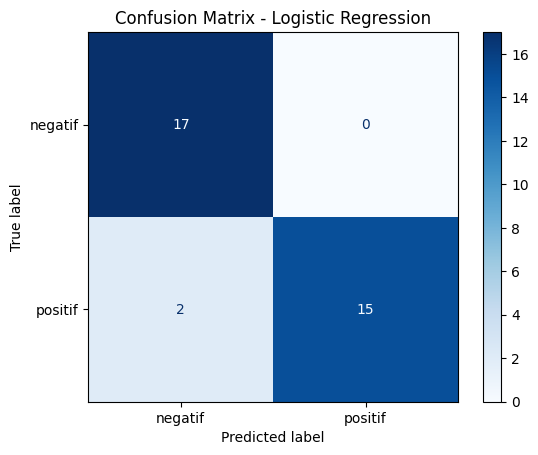

Model disimpan sebagai: model_logistic_regression_DPS.joblib

Evaluasi Model: Naive Bayes

Akurasi: 0.8529411764705882
Classification Report:
              precision    recall  f1-score   support

     negatif       0.83      0.88      0.86        17
     positif       0.88      0.82      0.85        17

    accuracy                           0.85        34
   macro avg       0.85      0.85      0.85        34
weighted avg       0.85      0.85      0.85        34



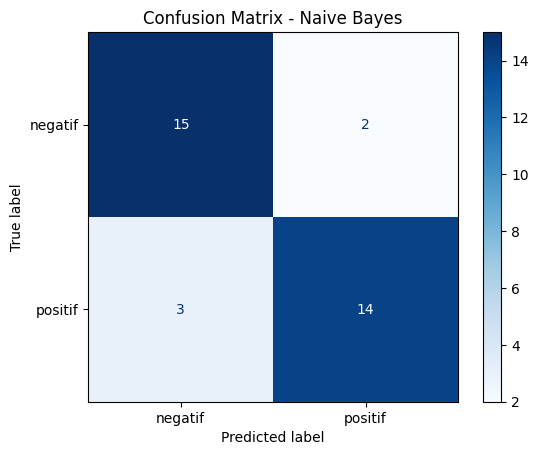

Model disimpan sebagai: model_naive_bayes_DPS.joblib

Evaluasi Model: Random Forest

Akurasi: 0.8235294117647058
Classification Report:
              precision    recall  f1-score   support

     negatif       0.76      0.94      0.84        17
     positif       0.92      0.71      0.80        17

    accuracy                           0.82        34
   macro avg       0.84      0.82      0.82        34
weighted avg       0.84      0.82      0.82        34



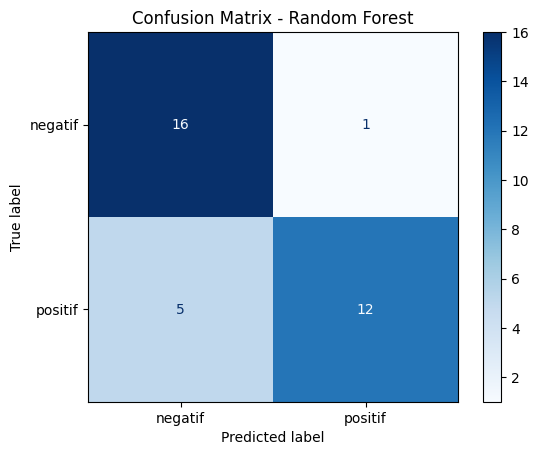

Model disimpan sebagai: model_random_forest_DPS.joblib

Evaluasi Model: XGBoost

Akurasi: 0.7058823529411765
Classification Report:
              precision    recall  f1-score   support

     negatif       0.73      0.65      0.69        17
     positif       0.68      0.76      0.72        17

    accuracy                           0.71        34
   macro avg       0.71      0.71      0.70        34
weighted avg       0.71      0.71      0.70        34



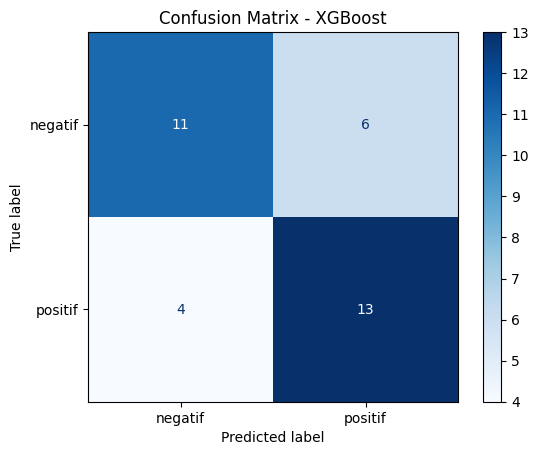

Model disimpan sebagai: model_xgboost_DPS.joblib

Evaluasi Model: SVM

Akurasi: 0.9705882352941176
Classification Report:
              precision    recall  f1-score   support

     negatif       1.00      0.94      0.97        17
     positif       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



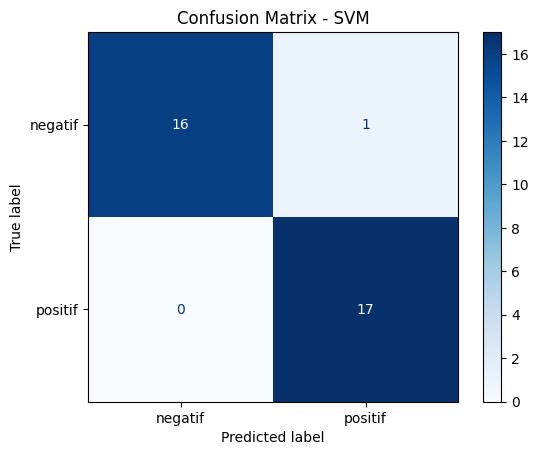

Model disimpan sebagai: model_svm_DPS.joblib


In [42]:
# Load data
df_train = pd.read_csv("data_train_DPS.csv")
df_test = pd.read_csv("data_test_DPS.csv")

X_train_text = df_train['stopword_str']
y_train = df_train['sentiment']
X_test_text = df_test['stopword_str']
y_test = df_test['sentiment']

# Encode label ke angka
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Load TF-IDF vectorizer
tfidf = joblib.load("vectorizer_tfidf_DPS.joblib") 

# Transform teks menjadi vektor TF-IDF
X_train = tfidf.transform(X_train_text)
X_test = tfidf.transform(X_test_text)

# Daftar model
models = {
    "Logistic Regression": LogisticRegression(C=0.1, penalty='l2', solver='saga', max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', n_estimators=200, max_depth=5, learning_rate=1.0, subsample=1.0),
    "SVM": SVC(kernel='linear', random_state=42)
}

# Latih, evaluasi, dan simpan model
for name, model in models.items():
    print(f"\nEvaluasi Model: {name}\n")
    
    # Latih model
    model.fit(X_train, y_train_enc)
    
    # Prediksi
    y_pred_enc = model.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)

    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    print("Akurasi:", acc)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Tampilkan confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

    # Simpan model
    filename = f"model_{name.lower().replace(' ', '_')}_DPS.joblib"
    joblib.dump(model, filename)
    print(f"Model disimpan sebagai: {filename}")
    joblib.dump(le, "label_encoder_DPS.joblib")

# **8. Membangun WordCloud**
Setelah melatih model machine learning, selanjutnya dilakukan pengelompokan kata-kata yang sering muncul.

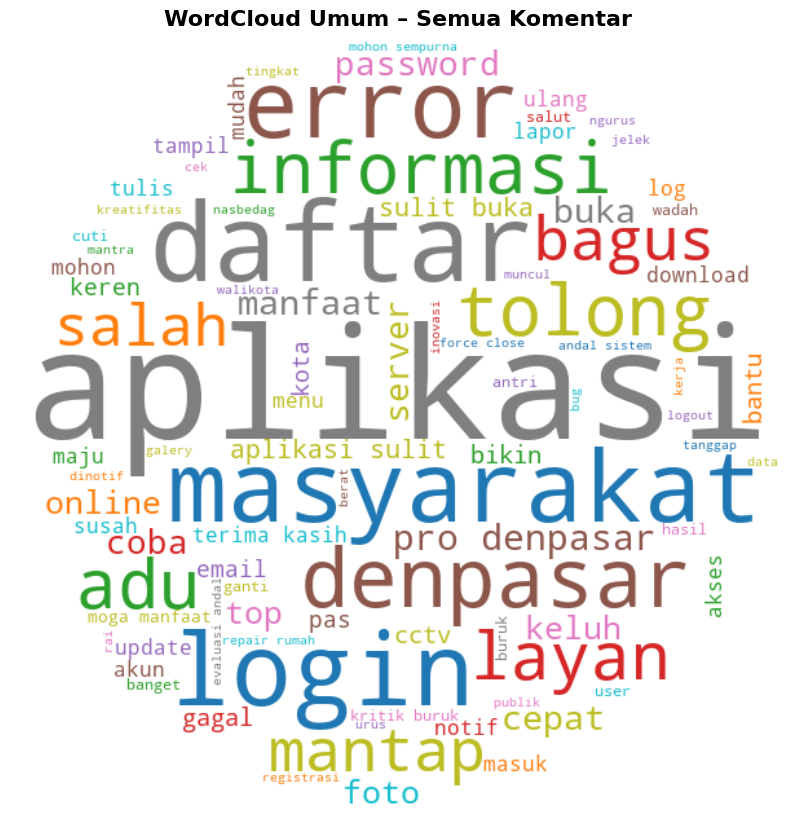

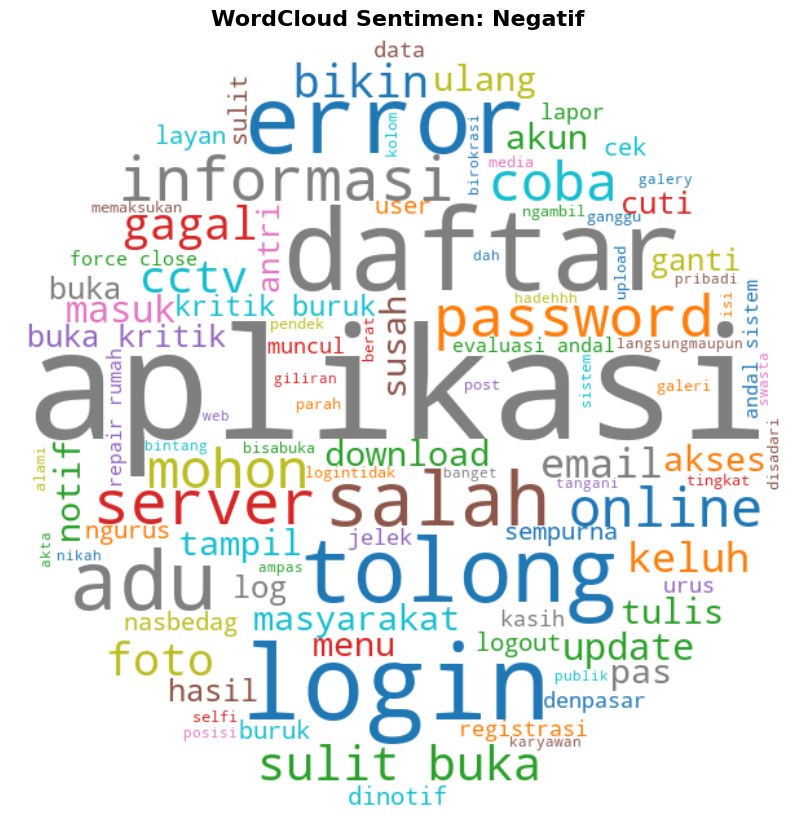

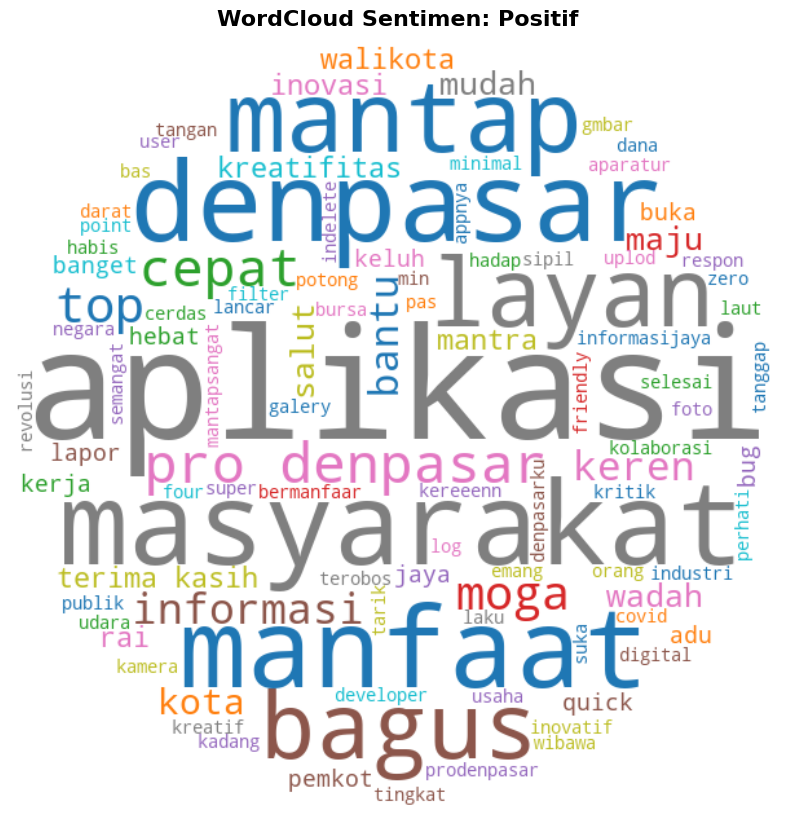

In [45]:
def create_circle_mask(diameter=600):
    "Membuat mask berbentuk lingkaran dengan ukuran diameter tertentu"
    x, y = np.ogrid[:diameter, :diameter]
    center = diameter // 2
    radius = diameter // 2
    mask = (x - center)**2 + (y - center)**2 > radius**2
    mask = 255 * mask.astype(int)
    return mask

def generate_wordcloud(text, title):
    circle_mask = create_circle_mask(600)

    wordcloud = WordCloud(
        width=200, height=200,
        background_color='white',
        colormap='tab10',
        max_words=100,
        prefer_horizontal=0.9,
        min_font_size=10,
        max_font_size=120,
        random_state=42,
        mask=circle_mask
    ).generate(text)

    plt.figure(figsize=(8, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout(pad=0)
    plt.show()

# WordCloud semua komentar (umum)
all_text = ' '.join(datafile['stopword_str'])
generate_wordcloud(all_text, "WordCloud Umum – Semua Komentar")

# WordCloud per sentimen (positif, negatif)
for label in datafile['sentiment'].unique():
    sentimen_text = ' '.join(datafile[datafile['sentiment'] == label]['stopword_str'])
    generate_wordcloud(sentimen_text, f"WordCloud Sentimen: {label.capitalize()}")

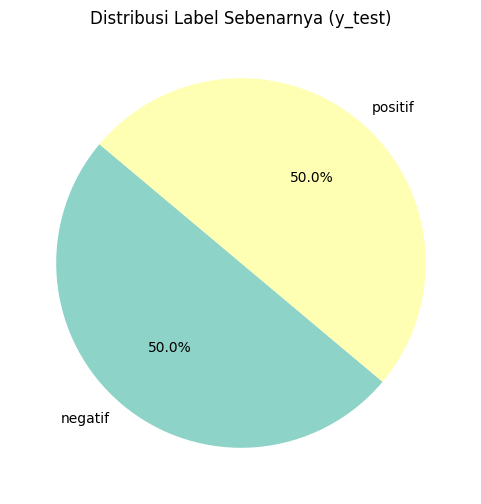

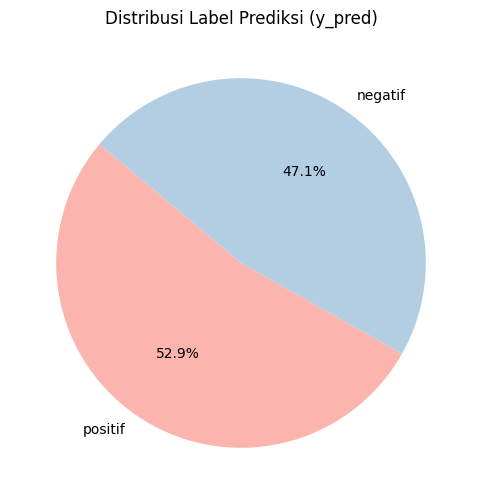

In [46]:
# Distribusi label sebenarnya (y_test)
plt.figure(figsize=(6, 6))
y_test.value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors,
    labels=y_test.value_counts().index
)
plt.title("Distribusi Label Sebenarnya (y_test)")
plt.ylabel('')
plt.show()

# Distribusi label hasil prediksi (y_pred)
plt.figure(figsize=(6, 6))
pd.Series(y_pred).value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors,
    labels=pd.Series(y_pred).value_counts().index
)
plt.title("Distribusi Label Prediksi (y_pred)")
plt.ylabel('')
plt.show()

In [47]:
emosi_lexicon = {
    "senang": [
        "terima kasih", "suksma", "mantap", "bagus", "baik", "puas", "makasih",
        "moga lancar", "nggih", "selamat", "hebat", "nyaman", "ideal", "makmur", "unggul",
    ],
    "sedih": [
        "sedih", "kecewa", "miris", "nyeri", "parah", "sayang", "capek", "buruk", "rusak",
        "banjir", "lubang", "bobol", "buntu", "kotor", "bahaya", "gelap", "begajulan", "tidak rata",
        "tidak nyaman", "tidak fungsi", "tidak profesional"
    ],
    "marah": [
        "ngapain", "aneh", "kenapa", "kok bisa", "gimana", "tidak tahu", "kenapa belum",
        "asal-asalan", "tidak sesuai", "salah", "tidak mempan", "komplain", "tidak adil", "parah", "jelek", "kurang"
    ],
    "optimis": [
        "optimis", "harap", "semoga", "astungkara", "yakin", "mudah-mudahan",
        "moga", "harap", "lanjut", "segera", "dalam tahap", "akan baik", "akan aspal",
        "akan diperbaiki", "masuk list", "masuk proyek", "teruskan", "ditindaklanjuti"
    ],
    "ragu-ragu": [
        "mungkin", "bingung", "gatau", "tidak tahu", "ragu", "entahlah", "kurang tahu",
        "belum pasti", "kayaknya", "seperti", "kalau", "kira-kira"
    ],
    "kritis": [
        "cek", "tolong", "kapan", "kenapa", "harap", "koordinasi", "perlu perhatian",
        "tolong atensi", "apakah", "harus", "bagaimana", "seharusnya", "kenapa tidak", "mohon",
    ]
}
joblib.dump(emosi_lexicon, "emosi_lexicon.joblib")

['emosi_lexicon.joblib']

In [48]:
# Load semua
vectorizer = joblib.load("vectorizer_tfidf_DPS.joblib")
model_sentimen = joblib.load("model_logistic_regression_DPS.joblib")
emosi_lexicon = joblib.load("emosi_lexicon.joblib")
le = joblib.load("label_encoder_DPS.joblib")

def predict_sentiment(text):
    text_clean = text.lower().strip()
    text_vector = vectorizer.transform([text_clean])
    pred_sentimen_enc = model_sentimen.predict(text_vector)[0]
    pred_sentimen = le.inverse_transform([pred_sentimen_enc])[0]  # ubah angka ke label asli
    pred_emosi = deteksi_emosi(text_clean)
    return pred_sentimen, pred_emosi

def deteksi_emosi(teks):
    for emosi, kata_kunci in emosi_lexicon.items():
        for kata in kata_kunci:
            if kata in teks:
                return emosi
    return "netral"

In [50]:
# Uji coba
text = "aplikasi jelek sekali lemot"
sentimen, emosi = predict_sentiment(text)
print("Teks:", text)
print("Sentimen:", sentimen)
print("Emosi:", emosi)

Teks: aplikasi jelek sekali lemot
Sentimen: negatif
Emosi: marah
